In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import seaborn

PARTE 2

In [9]:
df = pd.read_excel(r"H:\python\python-tecTI\dados\Tabelas\Tabela_13_Meio_de_transporte.xlsx")

In [25]:
tabela_mBranca = df.iloc[2:, 0:7].copy()
tabela_mBranca.columns = [
    "regiao",
    "A pé",
    "Bicicleta",
    "Motocicleta ou Mototaxi",
    "Automóvel, taxi ou assemelhados",
    "Transporte coletivo",
    "Outros"
]
tabela_mBranca = tabela_mBranca.reset_index(drop=True)

for col in tabela_mBranca.columns[1:]:
    tabela_mBranca[col] = pd.to_numeric(tabela_mBranca[col], errors="coerce")

tabela_mPreta = df.iloc[2:, [0,7,8,9,10,11,12]].copy()
tabela_mPreta.columns = [
    "regiao",
    "A pé",
    "Bicicleta",
    "Motocicleta ou Mototaxi",
    "Automóvel, taxi ou assemelhados",
    "Transporte coletivo",
    "Outros"
]
tabela_mPreta = tabela_mPreta.reset_index(drop=True)

for col in tabela_mPreta.columns[1:]:
    tabela_mPreta[col] = pd.to_numeric(tabela_mPreta[col], errors="coerce")

tabela_mIndigena = df.iloc[2:, [0,13,14,15,16,17,18]].copy()
tabela_mIndigena.columns = [
    "regiao",
    "A pé",
    "Bicicleta",
    "Motocicleta ou Mototaxi",
    "Automóvel, taxi ou assemelhados",
    "Transporte coletivo",
    "Outros"
]
tabela_mIndigena = tabela_mIndigena.reset_index(drop=True)

for col in tabela_mIndigena.columns[1:]:
    tabela_mIndigena[col] = pd.to_numeric(tabela_mIndigena[col], errors="coerce")

In [38]:
tabela_mIndigena_Estado = tabela_mIndigena.iloc[6:33, :].copy()
tabela_mPreta_Estado = tabela_mPreta.iloc[6:33, :].copy()
tabela_mBranca_Estado = tabela_mBranca.iloc[6:33, :].copy()

In [39]:
tabela_mIndigena_Estado

,regiao,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros
6,Rondônia,36.3,17.8,29.9,13.4,1.9,0.6
7,Acre,56.7,1.9,16.5,11.4,6.8,6.7
8,Amazonas,49.0,3.6,17.5,6.3,8.7,14.9
9,Roraima,38.6,6.6,25.4,20.6,7.3,1.4
10,Pará,45.7,5.9,18.5,8.2,16.9,4.7
11,Amapá,53.0,NaN,2.4,10.4,10.3,24.0
12,Tocantins,51.4,7.0,19.7,11.7,8.7,1.4
13,Maranhão,43.7,3.3,29.8,7.3,15.8,NaN
14,Piauí,25.7,6.5,35.3,11.2,21.2,NaN
15,Ceará,34.8,8.0,21.4,11.1,23.7,1.1


In [20]:
tabela_mPreta

,regiao,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros
0,Brasil,24.8,5.2,14.2,20.6,34.6,0.6
1,Norte,21.3,8.6,27.7,19.5,20.8,2.1
2,Nordeste,31.7,4.1,20.8,16.9,26.0,0.6
3,Sudeste,23.0,4.5,7.0,19.5,45.5,0.5
4,Sul,24.0,5.5,8.6,29.2,32.2,0.5
...,...,...,...,...,...,...,...
5598,Vianópolis (GO),25.4,33.0,11.2,28.2,1.8,0.4
5599,Vicentinópolis (GO),38.1,1.4,26.4,14.3,19.0,0.9
5600,Vila Boa (GO),33.7,35.9,3.1,15.9,11.5,NaN
5601,Vila Propício (GO),41.8,13.4,19.3,19.4,6.0,NaN


In [21]:
tabela_mBranca

,regiao,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros
0,Brasil,19.4,3.2,9.9,41.8,25.2,0.5
1,Norte,15.2,5.9,24.5,35.1,17.9,1.3
2,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5
3,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5
4,Sul,20.8,3.5,7.3,48.0,20.0,0.5
...,...,...,...,...,...,...,...
5598,Vianópolis (GO),19.1,20.0,14.6,43.3,3.1,NaN
5599,Vicentinópolis (GO),37.1,1.2,25.6,20.7,14.3,1.1
5600,Vila Boa (GO),14.6,29.0,18.8,33.0,4.6,NaN
5601,Vila Propício (GO),40.9,13.3,18.5,22.9,4.4,NaN


PARTE 1

In [29]:
bruto = pd.read_excel(r"H:\python\python-tecTI\dados\Tabelas\Tabela_13_Meio_de_transporte.xlsx", sheet_name="Exemplo gráfico Brasil", skiprows=1)

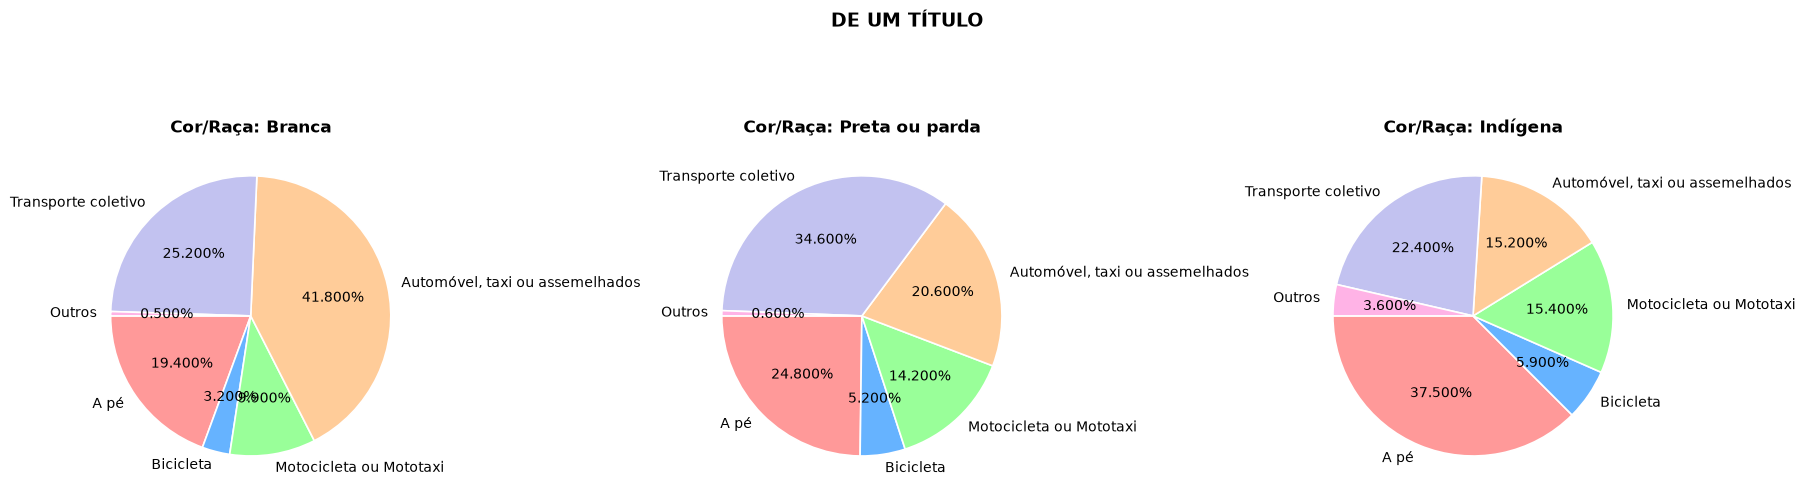

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']

grupos = ['Branca', 'Preta ou parda', 'Indígena']

for i, col in enumerate(grupos):
  axes[i].pie(
      bruto[col],
      labels=bruto['Meio de transporte/cor ou raça'],
      autopct='%1.3f%%',  
      startangle=180,  
      colors=cores,
      wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
  )
  axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'DE UM TÍTULO',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300)
plt.show()

Transporte Coletivo: Mulheres Pretas ou Pardas e Indígenas apresentam uma dependência substancialmente maior do transporte público em comparação às mulheres Brancas. (Exemplo: A diferença entre mulheres Pretas/Pardas e Brancas no uso de transporte coletivo é de X%).
Carro: O uso de transporte individual motorizado privado (carro) é predominantemente concentrado no grupo de mulheres Brancas, evidenciando maior poder aquisitivo médio. (Exemplo: A diferença entre mulheres Brancas e Pretas no uso de carro é de Y%).
Modos Ativos (A pé / Bicicleta): O deslocamento por bicicleta ou caminhada possui maior representação proporcional entre mulheres Indígenas e Pretas ou Pardas, indicando barreiras no acesso a transportes motorizados ou dinâmicas locais específicas de mobilidade. (Exemplo: A diferença entre mulheres Indígenas e Brancas no uso de bicicleta é de Z%).